## Load and inspect data

In [1]:
import pandas as pd

df = pd.read_excel('/Users/carloshassneto/Documents/Python_Projects/Coffee_Sales_Project/data//raw/coffee_shop_sales.xlsx',sheet_name='Transactions')

In [2]:
pd.ExcelFile('/Users/carloshassneto/Documents/Python_Projects/Coffee_Sales_Project/data/raw/coffee_shop_sales.xlsx').sheet_names

['Transactions']

In [3]:
df.head()


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(4), object(1), str(4)
memory usage: 12.5+ MB


,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [24]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['hour'] = pd.to_datetime(df['transaction_time']).dt.hour
df['day'] = df['transaction_date'].dt.day_name()
df['month'] = df['transaction_date'].dt.month_name()

In [29]:
df['revenue'] = df['transaction_qty'] * df['unit_price']

In [31]:
df[['transaction_time', 'hour']].head()

,transaction_time,hour
0,1900-01-01 07:06:11,7
1,1900-01-01 07:08:56,7
2,1900-01-01 07:14:04,7
3,1900-01-01 07:20:24,7
4,1900-01-01 07:22:41,7


In [32]:
df.groupby('hour')['revenue'].sum()


hour
6     21900.27
7     63526.47
8     82699.87
9     85169.53
10    88673.39
11    46319.14
12    40192.79
13    40367.45
14    41304.74
15    41733.10
16    41122.75
17    40134.31
18    34286.20
19    28446.68
20     2935.64
Name: revenue, dtype: float64

In [33]:
df.groupby('hour')['revenue'].sum().sort_values(ascending=False)

hour
10    88673.39
9     85169.53
8     82699.87
7     63526.47
11    46319.14
15    41733.10
14    41304.74
16    41122.75
13    40367.45
12    40192.79
17    40134.31
18    34286.20
19    28446.68
6     21900.27
20     2935.64
Name: revenue, dtype: float64

In [34]:
df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: revenue, dtype: float64

In [35]:
df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: revenue, dtype: float64

In [36]:
df.groupby('day')['revenue'].sum().sort_values(ascending=False)

day
Monday       101677.28
Friday       101373.00
Thursday     100767.78
Wednesday    100313.54
Tuesday       99455.94
Sunday        98330.31
Saturday      96894.48
Name: revenue, dtype: float64

In [37]:
df.groupby('product_type')['revenue'].sum().sort_values(ascending=False)

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Pastry                   25655.99
Brewed Green tea         23852.50
Biscotti                 19793.53
Premium Beans            14583.50
Organic Beans             8509.50
Housewares                7444.00
Gourmet Beans             6798.00
Clothing                  6163.00
Regular syrup             6084.80
Espresso Beans            5560.25
Chai tea                  4301.25
House blend Beans         3294.00
Herbal tea                2729.75
Drinking Chocolate        2728.04
Black tea                 2711.85
Sugar free syrup          2324.00
Organic Chocolate         1679.60
Green tea                 1470.75
Green beans               1340.00
N

In [43]:
pareto = df.groupby('product_type')['revenue'].sum().reset_index()

pareto = pareto.sort_values(by ='revenue', ascending=False)
pareto['cumulative'] = pareto['revenue'].cumsum()
pareto['cumulative_pct'] = pareto['cumulative'] / pareto['revenue'].sum() * 100

pareto.head(11)

,product_type,revenue,cumulative,cumulative_pct
0,Barista Espresso,91406.20,91406.20,13.080221
4,Brewed Chai tea,77081.95,168488.15,24.110644
17,Hot chocolate,72416.00,240904.15,34.473369
13,Gourmet brewed coffee,70034.60,310938.75,44.495315
3,Brewed Black tea,47932.00,358870.75,51.354382
6,Brewed herbal tea,47539.50,406410.25,58.157281
25,Premium brewed coffee,38781.15,445191.40,63.706861
22,Organic brewed coffee,37746.50,482937.90,69.108383
27,Scone,36866.12,519804.02,74.383922
10,Drip coffee,31984.00,551788.02,78.960831


In [45]:
pareto[pareto['cumulative_pct'] <= 80]

,product_type,revenue,cumulative,cumulative_pct
0,Barista Espresso,91406.20,91406.20,13.080221
4,Brewed Chai tea,77081.95,168488.15,24.110644
17,Hot chocolate,72416.00,240904.15,34.473369
13,Gourmet brewed coffee,70034.60,310938.75,44.495315
3,Brewed Black tea,47932.00,358870.75,51.354382
6,Brewed herbal tea,47539.50,406410.25,58.157281
25,Premium brewed coffee,38781.15,445191.40,63.706861
22,Organic brewed coffee,37746.50,482937.90,69.108383
27,Scone,36866.12,519804.02,74.383922
10,Drip coffee,31984.00,551788.02,78.960831


In [46]:
top_products = top_products = pareto[pareto['cumulative_pct'] <= 80]['product_type']

In [47]:
pivot = df.pivot_table(
    index='hour',
    columns='product_type',
    values='revenue',
    aggfunc='sum'
)

pivot_top = pivot[top_products]

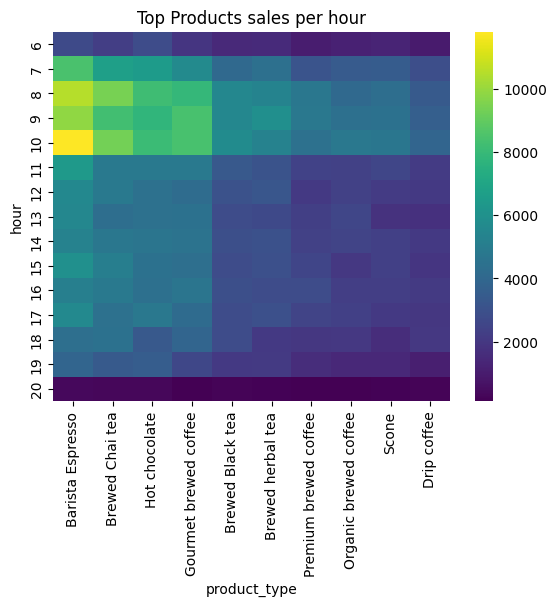

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(pivot_top, cmap='viridis')
plt.title('Top Products sales per hour')
plt.show()

In [51]:
pivot_pct = pivot_top.div(pivot_top.sum(axis=1), axis=0)

In [52]:
pivot_pct.idxmax(axis=0)

product_type
Barista Espresso         10
Brewed Chai tea          18
Hot chocolate             6
Gourmet brewed coffee    13
Brewed Black tea         18
Brewed herbal tea        12
Premium brewed coffee    16
Organic brewed coffee    13
Scone                     6
Drip coffee              20
dtype: int32

In [53]:
pivot_pct.head()
pivot_pct.idxmax(axis=1)

hour
6        Hot chocolate
7     Barista Espresso
8     Barista Espresso
9     Barista Espresso
10    Barista Espresso
11    Barista Espresso
12    Barista Espresso
13    Barista Espresso
14    Barista Espresso
15    Barista Espresso
16    Barista Espresso
17    Barista Espresso
18     Brewed Chai tea
19    Barista Espresso
20    Barista Espresso
dtype: str

In [54]:
pivot_no_espresso = pivot_top.drop(columns=['Barista Espresso'])

pivot_no_espresso.idxmax(axis=1)

hour
6             Hot chocolate
7           Brewed Chai tea
8           Brewed Chai tea
9     Gourmet brewed coffee
10          Brewed Chai tea
11            Hot chocolate
12          Brewed Chai tea
13    Gourmet brewed coffee
14          Brewed Chai tea
15          Brewed Chai tea
16          Brewed Chai tea
17            Hot chocolate
18          Brewed Chai tea
19            Hot chocolate
20            Hot chocolate
dtype: str

In [55]:
pivot_pct.round(2)

product_type,Barista Espresso,Brewed Chai tea,Hot chocolate,Gourmet brewed coffee,Brewed Black tea,Brewed herbal tea,Premium brewed coffee,Organic brewed coffee,Scone,Drip coffee
hour,,,,,,,,,,
6,0.16,0.13,0.16,0.11,0.09,0.09,0.06,0.07,0.07,0.06
7,0.17,0.14,0.13,0.12,0.08,0.09,0.07,0.07,0.07,0.06
8,0.17,0.15,0.13,0.12,0.09,0.08,0.08,0.06,0.07,0.05
9,0.16,0.13,0.12,0.13,0.09,0.09,0.08,0.07,0.07,0.06
10,0.18,0.14,0.12,0.13,0.09,0.08,0.07,0.07,0.07,0.06
11,0.17,0.13,0.13,0.13,0.09,0.08,0.07,0.06,0.07,0.06
12,0.16,0.14,0.13,0.12,0.09,0.10,0.06,0.07,0.06,0.06
13,0.17,0.13,0.14,0.14,0.09,0.08,0.07,0.08,0.05,0.05
14,0.15,0.14,0.13,0.13,0.09,0.09,0.07,0.07,0.07,0.06


In [58]:
morning = df[df['hour'] <= 11]
afternoon = df[df['hour'] >= 12]

morning.groupby('product_type')['revenue'].sum().sort_values(ascending=False)
afternoon.groupby('product_type')['revenue'].sum().sort_values(ascending=False)

product_type
Barista Espresso         41640.25
Brewed Chai tea          36407.00
Hot chocolate            34260.50
Gourmet brewed coffee    32968.90
Brewed Black tea         22317.00
Brewed herbal tea        22018.50
Premium brewed coffee    18132.50
Organic brewed coffee    17560.50
Scone                    16053.25
Drip coffee              15178.50
Brewed Green tea         11053.00
Pastry                    9380.98
Biscotti                  8718.71
Premium Beans             3473.50
Organic Beans             3010.50
Housewares                2741.00
Gourmet Beans             2478.00
Clothing                  2296.00
Regular syrup             1831.20
Espresso Beans            1590.70
Chai tea                  1494.35
Black tea                 1029.25
House blend Beans          954.00
Herbal tea                 832.35
Sugar free syrup           800.80
Drinking Chocolate         769.47
Organic Chocolate          661.20
Green tea                  471.75
Green beans                400.00
N

In [59]:
df_export = df.copy()

# Select relevant columns
df_export = df_export[[
    'transaction_date',
    'hour',
    'store_location',
    'product_category',
    'product_type',
    'transaction_qty',
    'unit_price',
    'revenue'
]]

In [60]:
df_export['month_num'] = df_export['transaction_date'].dt.month
df_export['day_num'] = df_export['transaction_date'].dt.dayofweek

In [62]:
df_export.to_csv('../data/coffee_sales_clean.csv', index=False)